In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [29]:
# Load the clustered dataset directly
df = pd.read_csv('baringo_clustered_data.csv')

# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4018 entries, 2010-01-01 to 2020-12-31
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4018 non-null   int64  
 1   temperature    4018 non-null   float64
 2   dew_point      4018 non-null   float64
 3   humidity       4018 non-null   float64
 4   wind_speed     4018 non-null   float64
 5   pressure       4018 non-null   float64
 6   precipitation  4018 non-null   float64
 7   region_id      4018 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 282.5 KB


In [30]:
# Define flood probability function
def calculate_flood_probability(df):
    df['3_day_cum_precip'] = df['precipitation'].rolling(window=3).sum()

    # Normalize features (min-max scaling)
    df['norm_precip'] = df['3_day_cum_precip'] / df['3_day_cum_precip'].max()
    df['norm_humidity'] = df['humidity'] / df['humidity'].max()
    df['norm_dew_point'] = df['dew_point'] / df['dew_point'].max()
    df['norm_pressure'] = 1 - (df['pressure'] / df['pressure'].max())  # Inverse scaling

    # Weighted sum of features (tuned weights based on analysis)
    df['flood_probability'] = (
        (df['norm_precip'] * 0.5) + 
        (df['norm_humidity'] * 0.2) + 
        (df['norm_dew_point'] * 0.2) + 
        (df['norm_pressure'] * 0.1)
    )

    # Clip values to ensure probability range (0 to 1)
    df['flood_probability'] = df['flood_probability'].clip(0, 1)

    return df

df = calculate_flood_probability(df)

In [31]:
# Select features for LSTM
features = ['temperature', 'dew_point', 'humidity', 'wind_speed', 'pressure', 'precipitation']
target = 'flood_probability'  # Predicting precipitation as a proxy for flood risk

df.head()


,Unnamed: 0,temperature,dew_point,humidity,wind_speed,pressure,precipitation,region_id,3_day_cum_precip,norm_precip,norm_humidity,norm_dew_point,norm_pressure,flood_probability
time,,,,,,,,,,,,,,
2010-01-01,0,18.0,14.0,85.0,5.0,29.91,23.0,3,NaN,NaN,0.867347,0.823529,0.005982,NaN
2010-01-02,1,18.0,16.0,89.0,6.0,29.94,28.8,3,NaN,NaN,0.908163,0.941176,0.004985,NaN
2010-01-03,2,18.0,14.0,82.0,10.0,29.94,2.5,0,54.3,0.265396,0.836735,0.823529,0.004985,0.465249
2010-01-04,3,18.0,13.0,76.0,9.0,29.94,1.7,2,33.0,0.161290,0.775510,0.764706,0.004985,0.389187
2010-01-05,4,19.0,12.0,69.0,10.0,29.91,1.3,2,5.5,0.026882,0.704082,0.705882,0.005982,0.296032


In [32]:
# Normalize features per region
scalers = {}  # Store scalers for inverse transform
df_scaled = df.copy()

for region in df['region_id'].unique():
    scaler = MinMaxScaler()
    region_data = df[df['region_id'] == region]
    df_scaled.loc[df['region_id'] == region, features] = scaler.fit_transform(region_data[features])
    scalers[region] = scaler

In [33]:
# Function to create LSTM sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][-1])  # Predicting next precipitation
    return np.array(X), np.array(y)

In [34]:
# Prepare data for each region
seq_lengths = {0: 15, 1: 7, 2: 15, 3: 5}  # Lookback period
X_train, y_train, X_test, y_test = {}, {}, {}, {}

for region in df['region_id'].unique():
    region_data = df_scaled[df_scaled['region_id'] == region][features].values
    train_size = int(len(region_data) * 0.8)
    seq_length = seq_lengths[region]
    
    X, y = create_sequences(region_data, seq_length)
    X_train[region], y_train[region] = X[:train_size], y[:train_size]
    X_test[region], y_test[region] = X[train_size:], y[train_size:]

In [ ]:
# Build LSTM model
def build_lstm_model(region, input_shape):
    model = Sequential()
    
    model.add(Bidirectional(LSTM(50, return_sequences=True), input_shape=input_shape))
    model.add(Dropout(0.4))

    model.add(Bidirectional(LSTM(50, return_sequences=False)))
    model.add(Dropout(0.4))

    model.add(Dense(30, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)  # Reduced LR for stability
    model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber())  # More robust loss function
    
    return model

In [36]:
# Train models for each region
models = {}
epochs_dict = {0: 50, 1: 100, 2: 50, 3: 100}  # More epochs for Regions 1 & 3

for region in df['region_id'].unique():
    model = build_lstm_model(region, (seq_lengths[region], len(features)))
    print(f"\nTraining model for Region {region}...\n")
    
    model.fit(X_train[region], y_train[region], epochs=50, batch_size=16,
              validation_data=(X_test[region], y_test[region]), verbose=1)
    
    models[region] = model

/home/ronny/.local/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training model for Region 3...

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - loss: 0.0208 - val_loss: 0.0199
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0149 - val_loss: 0.0224
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0111 - val_loss: 0.0214
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0140 - val_loss: 0.0224
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0117 - val_loss: 0.0226
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0130 - val_loss: 0.0225
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0107 - val_loss: 0.0219
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0115 - val_loss: 0.0218
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0112 - val_loss: 0.0231
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0160 - val_loss: 0.0228
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0142 - val_loss: 0.0226
Epoch 12/50
19/19 ━━━━━━━━━━━

In [37]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 422ms/step

Region 3:
Mean Squared Error: 391.5924
Mean Absolute Error: 12.7034
Root Mean Squared Error: 19.7887
R2 Score: -0.3049


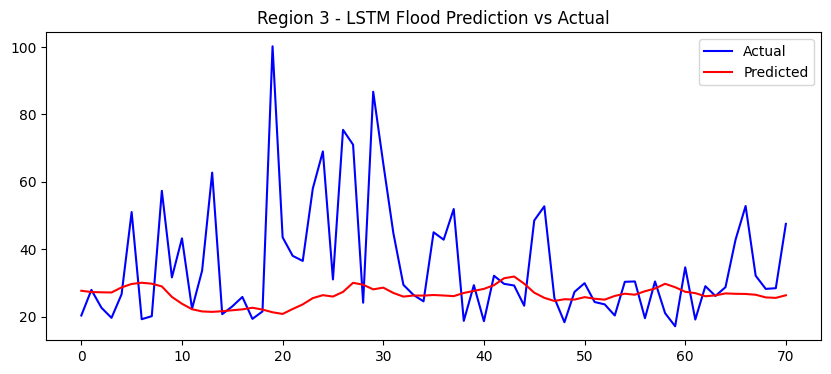

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step

Region 0:
Mean Squared Error: 24.8631
Mean Absolute Error: 4.0057
Root Mean Squared Error: 4.9863
R2 Score: 0.1516


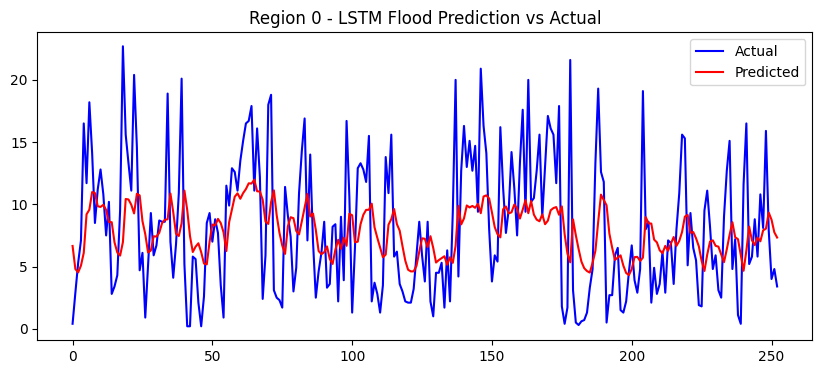

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step

Region 2:
Mean Squared Error: 30.3017
Mean Absolute Error: 4.3136
Root Mean Squared Error: 5.5047
R2 Score: 0.0859


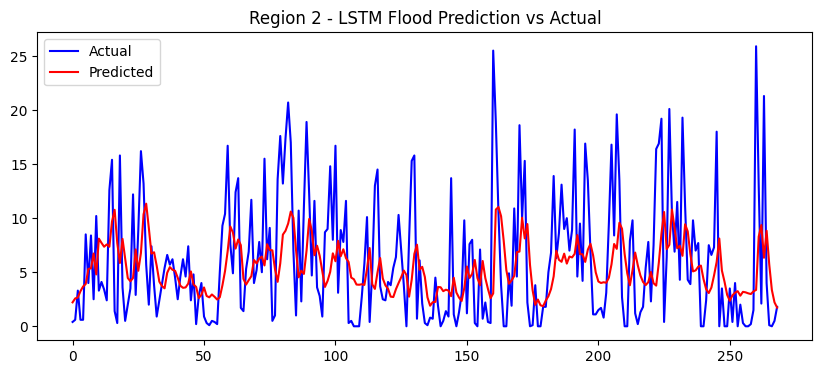

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step

Region 1:
Mean Squared Error: 1.8368
Mean Absolute Error: 0.6934
Root Mean Squared Error: 1.3553
R2 Score: 0.2027


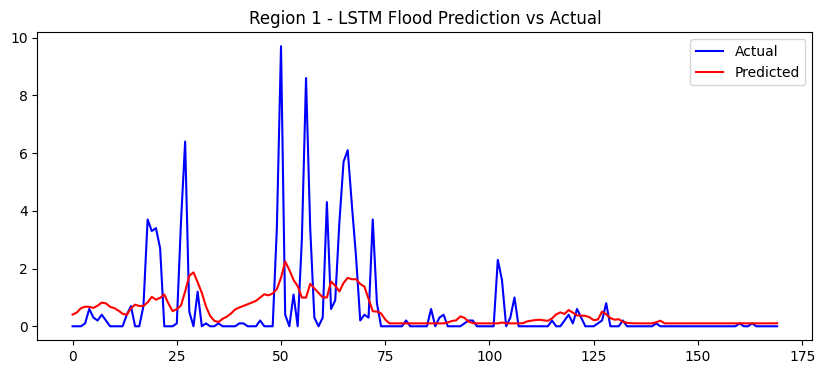

In [38]:
# Evaluate model performance
for region in df['region_id'].unique():
    y_pred = models[region].predict(X_test[region])
    
    y_pred_inv = scalers[region].inverse_transform(
        np.concatenate((np.zeros((y_pred.shape[0], len(features)-1)), y_pred), axis=1))[:, -1]
    
    y_test_inv = scalers[region].inverse_transform(
        np.concatenate((np.zeros((y_test[region].shape[0], len(features)-1)), y_test[region].reshape(-1, 1)), axis=1))[:, -1]
    
    # Calculate evaluation metrics
    mse = mean_squared_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    r2 = r2_score(y_test_inv, y_pred_inv)
    
    print(f"\nRegion {region}:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

    # Plot predictions vs actual values
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_inv, label='Actual', color='blue')
    plt.plot(y_pred_inv, label='Predicted', color='red')
    plt.title(f'Region {region} - LSTM Flood Prediction vs Actual')
    plt.legend()
    plt.show()